In [1]:
# ============================================
# CELL 1 - Imports
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pulp
import json
import os
import warnings
warnings.filterwarnings('ignore')

print(f"✅ PuLP version: {pulp.__version__}")
print("✅ All libraries imported!")

✅ PuLP version: 3.3.0
✅ All libraries imported!


In [2]:
# ============================================
# CELL 2 - Equipment Status & RUL Predictions
# ============================================

# Simulate equipment with predicted RUL
# (In production this comes from Day 9/10 models)
np.random.seed(42)

n_equipment = 10

equipment_df = pd.DataFrame({
    'equipment_id'  : [f'EQ-{i:03d}' for i in range(1, n_equipment+1)],
    'equipment_type': np.random.choice(
        ['Turbine', 'Compressor', 'Pump'], n_equipment
    ),
    'predicted_rul' : np.random.randint(5, 120, n_equipment),
    'criticality'   : np.random.choice(
        ['High', 'Medium', 'Low'], n_equipment,
        p=[0.3, 0.4, 0.3]
    ),
    'last_maintained': pd.date_range(
        start='2024-01-01',
        periods=n_equipment,
        freq='15D'
    )
})

# Sort by RUL (most urgent first)
equipment_df = equipment_df.sort_values(
    'predicted_rul'
).reset_index(drop=True)

print("📊 Equipment Status:")
print("="*65)
print(equipment_df.to_string(index=False))
print("="*65)
print(f"\n⚠️  Critical (RUL < 30): "
      f"{(equipment_df['predicted_rul'] < 30).sum()} units")
print(f"⚠️  Warning  (RUL < 60): "
      f"{(equipment_df['predicted_rul'] < 60).sum()} units")

📊 Equipment Status:
equipment_id equipment_type  predicted_rul criticality last_maintained
      EQ-010           Pump              6      Medium      2024-05-15
      EQ-007           Pump              7        High      2024-03-31
      EQ-008     Compressor             26        High      2024-04-15
      EQ-006        Turbine             28      Medium      2024-03-16
      EQ-009           Pump             57      Medium      2024-04-30
      EQ-001           Pump             79         Low      2024-01-01
      EQ-002        Turbine             79         Low      2024-01-16
      EQ-003           Pump             92        High      2024-01-31
      EQ-004           Pump            104         Low      2024-02-15
      EQ-005        Turbine            108      Medium      2024-03-01

⚠️  Critical (RUL < 30): 4 units
⚠️  Warning  (RUL < 60): 5 units


In [3]:
# ============================================
# CELL 3 - Cost Matrix Definition
# ============================================

# Cost parameters (in USD)
COSTS = {
    # Downtime costs per hour
    'downtime_per_hour'    : 10000,

    # Repair costs by type
    'repair_turbine'       : 15000,
    'repair_compressor'    : 10000,
    'repair_pump'          : 5000,

    # Preventive maintenance costs
    'preventive_turbine'   : 3000,
    'preventive_compressor': 2000,
    'preventive_pump'      : 1000,

    # Technician costs
    'technician_hourly'    : 150,
    'maintenance_hours'    : 8,

    # Emergency multiplier
    'emergency_multiplier' : 3.0
}

# Scheduling horizon (days)
HORIZON = 14

# Available technicians per day
TECHNICIANS_PER_DAY = 3

# Max maintenance per day
MAX_MAINTENANCE_PER_DAY = 2

print("💰 COST MATRIX:")
print("="*45)
for key, val in COSTS.items():
    print(f"  {key:30s}: ${val:,}")
print("="*45)

# Calculate failure cost per equipment
def get_repair_cost(eq_type, emergency=False):
    base = {
        'Turbine'   : COSTS['repair_turbine'],
        'Compressor': COSTS['repair_compressor'],
        'Pump'      : COSTS['repair_pump']
    }.get(eq_type, COSTS['repair_pump'])

    if emergency:
        return base * COSTS['emergency_multiplier']
    return base

def get_preventive_cost(eq_type):
    return {
        'Turbine'   : COSTS['preventive_turbine'],
        'Compressor': COSTS['preventive_compressor'],
        'Pump'      : COSTS['preventive_pump']
    }.get(eq_type, COSTS['preventive_pump'])

# Add costs to equipment df
equipment_df['repair_cost'] = equipment_df[
    'equipment_type'
].apply(lambda x: get_repair_cost(x))

equipment_df['preventive_cost'] = equipment_df[
    'equipment_type'
].apply(lambda x: get_preventive_cost(x))

equipment_df['emergency_cost'] = equipment_df[
    'equipment_type'
].apply(lambda x: get_repair_cost(x, emergency=True))

print(f"\n📊 Equipment Costs:")
print(equipment_df[[
    'equipment_id', 'equipment_type',
    'predicted_rul', 'repair_cost',
    'preventive_cost', 'emergency_cost'
]].to_string(index=False))

💰 COST MATRIX:
  downtime_per_hour             : $10,000
  repair_turbine                : $15,000
  repair_compressor             : $10,000
  repair_pump                   : $5,000
  preventive_turbine            : $3,000
  preventive_compressor         : $2,000
  preventive_pump               : $1,000
  technician_hourly             : $150
  maintenance_hours             : $8
  emergency_multiplier          : $3.0

📊 Equipment Costs:
equipment_id equipment_type  predicted_rul  repair_cost  preventive_cost  emergency_cost
      EQ-010           Pump              6         5000             1000         15000.0
      EQ-007           Pump              7         5000             1000         15000.0
      EQ-008     Compressor             26        10000             2000         30000.0
      EQ-006        Turbine             28        15000             3000         45000.0
      EQ-009           Pump             57         5000             1000         15000.0
      EQ-001           Pum

In [4]:
# ============================================
# CELL 4 - PuLP Mixed Integer Linear Program
# ============================================

print("🔄 Building optimization model...")

# Initialize PuLP problem
prob = pulp.LpProblem(
    "Maintenance_Scheduling",
    pulp.LpMinimize
)

n_eq   = len(equipment_df)
days   = list(range(1, HORIZON + 1))
eq_ids = list(range(n_eq))

# ============================================
# Decision Variables
# ============================================

# x[i][d] = 1 if equipment i is maintained on day d
x = {}
for i in eq_ids:
    for d in days:
        x[i,d] = pulp.LpVariable(
            f"maintain_eq{i}_day{d}",
            cat='Binary'
        )

# failure[i] = 1 if equipment i fails (not maintained in time)
failure = {}
for i in eq_ids:
    failure[i] = pulp.LpVariable(
        f"failure_eq{i}",
        cat='Binary'
    )

# ============================================
# Objective Function: Minimize Total Cost
# ============================================

# Cost 1: Preventive maintenance cost
preventive_costs = pulp.lpSum([
    x[i,d] * equipment_df.loc[i, 'preventive_cost']
    for i in eq_ids
    for d in days
])

# Cost 2: Technician cost
technician_costs = pulp.lpSum([
    x[i,d] * COSTS['technician_hourly'] *
    COSTS['maintenance_hours']
    for i in eq_ids
    for d in days
])

# Cost 3: Failure/emergency cost
failure_costs = pulp.lpSum([
    failure[i] * equipment_df.loc[i, 'emergency_cost']
    for i in eq_ids
])

# Cost 4: Downtime risk cost
downtime_costs = pulp.lpSum([
    failure[i] * COSTS['downtime_per_hour'] * 24
    for i in eq_ids
])

# Total objective
prob += (preventive_costs + technician_costs +
         failure_costs + downtime_costs)

# ============================================
# Constraints
# ============================================

# Constraint 1: Each equipment maintained at most once
for i in eq_ids:
    prob += pulp.lpSum([x[i,d] for d in days]) <= 1, \
            f"max_one_maintenance_{i}"

# Constraint 2: Max maintenance per day
for d in days:
    prob += pulp.lpSum([x[i,d] for i in eq_ids]) <= \
            MAX_MAINTENANCE_PER_DAY, \
            f"max_daily_maintenance_{d}"

# Constraint 3: Technician availability
for d in days:
    prob += pulp.lpSum([x[i,d] for i in eq_ids]) <= \
            TECHNICIANS_PER_DAY, \
            f"technician_availability_{d}"

# Constraint 4: Equipment must be maintained before RUL=0
for i in eq_ids:
    rul = equipment_df.loc[i, 'predicted_rul']
    deadline = min(int(rul), HORIZON)

    if deadline > 0:
        # Must be maintained before deadline OR failure=1
        prob += (
            pulp.lpSum([x[i,d] for d in range(1, deadline+1)])
            + failure[i] >= 1
        ), f"maintain_before_failure_{i}"
    else:
        # Already critical
        prob += failure[i] == 1, \
                f"already_failed_{i}"

# Constraint 5: High criticality equipment priority
for i in eq_ids:
    if equipment_df.loc[i, 'criticality'] == 'High':
        rul      = equipment_df.loc[i, 'predicted_rul']
        deadline = min(int(rul * 0.8), HORIZON)
        if deadline > 0:
            prob += (
                pulp.lpSum([
                    x[i,d] for d in range(1, deadline+1)
                ]) + failure[i] >= 1
            ), f"priority_high_{i}"

print("✅ Optimization model built!")
print(f"📊 Variables   : {len(prob.variables())}")
print(f"📊 Constraints : {len(prob.constraints)}")

🔄 Building optimization model...
✅ Optimization model built!
📊 Variables   : 150
📊 Constraints : 51


In [5]:
# ============================================
# CELL 5 - Solve Optimization Problem
# ============================================

import time

print("🔄 Solving optimization problem...")
start_time = time.time()

# Solve
solver = pulp.PULP_CBC_CMD(msg=0)
prob.solve(solver)

solve_time = time.time() - start_time

print(f"\n✅ Optimization complete!")
print(f"⏱️  Solve time : {solve_time:.2f} seconds")
print(f"📊 Status     : {pulp.LpStatus[prob.status]}")
print(f"💰 Total Cost : ${pulp.value(prob.objective):,.2f}")

# Check target (< 30 seconds)
if solve_time < 30:
    print(f"✅ Solved in {solve_time:.2f}s < 30s target!")
else:
    print(f"⚠️  Solve time exceeded 30s target")

🔄 Solving optimization problem...

✅ Optimization complete!
⏱️  Solve time : 1.12 seconds
📊 Status     : Optimal
💰 Total Cost : $29,000.00
✅ Solved in 1.12s < 30s target!


In [6]:
# ============================================
# CELL 6 - Extract Optimal Schedule
# ============================================

schedule = []

for i in eq_ids:
    maintained    = False
    scheduled_day = None

    for d in days:
        if pulp.value(x[i,d]) == 1:
            maintained    = True
            scheduled_day = d
            break

    will_fail = pulp.value(failure[i]) == 1

    schedule.append({
        'equipment_id'   : equipment_df.loc[i, 'equipment_id'],
        'equipment_type' : equipment_df.loc[i, 'equipment_type'],
        'criticality'    : equipment_df.loc[i, 'criticality'],
        'predicted_rul'  : equipment_df.loc[i, 'predicted_rul'],
        'scheduled_day'  : scheduled_day if maintained else 'N/A',
        'status'         : '✅ Scheduled' if maintained
                           else '❌ Will Fail',
        'preventive_cost': equipment_df.loc[i, 'preventive_cost']
                           if maintained else 0,
        'failure_cost'   : equipment_df.loc[i, 'emergency_cost']
                           if will_fail else 0
    })

schedule_df = pd.DataFrame(schedule)

print("📋 OPTIMAL MAINTENANCE SCHEDULE:")
print("="*75)
print(schedule_df.to_string(index=False))
print("="*75)
print(f"\n✅ Scheduled : {(schedule_df['status']=='✅ Scheduled').sum()}")
print(f"❌ Will Fail : {(schedule_df['status']=='❌ Will Fail').sum()}")

📋 OPTIMAL MAINTENANCE SCHEDULE:
equipment_id equipment_type criticality  predicted_rul  scheduled_day      status  preventive_cost  failure_cost
      EQ-010           Pump      Medium              6              6 ✅ Scheduled             1000             0
      EQ-007           Pump        High              7              1 ✅ Scheduled             1000             0
      EQ-008     Compressor        High             26              9 ✅ Scheduled             2000             0
      EQ-006        Turbine      Medium             28              7 ✅ Scheduled             3000             0
      EQ-009           Pump      Medium             57              8 ✅ Scheduled             1000             0
      EQ-001           Pump         Low             79              3 ✅ Scheduled             1000             0
      EQ-002        Turbine         Low             79              3 ✅ Scheduled             3000             0
      EQ-003           Pump        High             92          

In [7]:
# ============================================
# CELL 7 - Save Schedule as JSON
# ============================================

os.makedirs('data/schedules', exist_ok=True)

# Convert to JSON
schedule_json = {
    'generated_at'   : pd.Timestamp.now().isoformat(),
    'horizon_days'   : HORIZON,
    'total_cost'     : pulp.value(prob.objective),
    'solve_time_sec' : round(solve_time, 2),
    'status'         : pulp.LpStatus[prob.status],
    'schedule'       : schedule_df.to_dict(orient='records')
}

with open('data/schedules/optimal_schedule.json', 'w') as f:
    json.dump(schedule_json, f, indent=2, default=str)

print("✅ Schedule saved to data/schedules/optimal_schedule.json")
print(f"\n📊 Schedule Summary:")
print(f"   Total Cost   : ${schedule_json['total_cost']:,.2f}")
print(f"   Solve Time   : {schedule_json['solve_time_sec']}s")
print(f"   Status       : {schedule_json['status']}")

✅ Schedule saved to data/schedules/optimal_schedule.json

📊 Schedule Summary:
   Total Cost   : $29,000.00
   Solve Time   : 1.12s
   Status       : Optimal


In [8]:
# ============================================
# CELL 8 - Sensitivity Analysis
# ============================================

print("🔄 Running sensitivity analysis...")

# Vary downtime cost and see how schedule changes
downtime_multipliers = [0.5, 1.0, 1.5, 2.0, 3.0]
total_costs          = []

for multiplier in downtime_multipliers:
    # Rebuild with different downtime cost
    prob_sens = pulp.LpProblem(
        f"Sensitivity_{multiplier}",
        pulp.LpMinimize
    )

    x_s = {}
    f_s = {}
    for i in eq_ids:
        f_s[i] = pulp.LpVariable(
            f"fail_{i}", cat='Binary'
        )
        for d in days:
            x_s[i,d] = pulp.LpVariable(
                f"x_{i}_{d}", cat='Binary'
            )

    # Modified objective
    prob_sens += (
        pulp.lpSum([
            x_s[i,d] * equipment_df.loc[i,'preventive_cost']
            for i in eq_ids for d in days
        ]) +
        pulp.lpSum([
            f_s[i] * equipment_df.loc[i,'emergency_cost'] *
            multiplier
            for i in eq_ids
        ])
    )

    # Same constraints
    for i in eq_ids:
        prob_sens += pulp.lpSum(
            [x_s[i,d] for d in days]
        ) <= 1
        rul      = equipment_df.loc[i, 'predicted_rul']
        deadline = min(int(rul), HORIZON)
        if deadline > 0:
            prob_sens += (
                pulp.lpSum([
                    x_s[i,d]
                    for d in range(1, deadline+1)
                ]) + f_s[i] >= 1
            )
        else:
            prob_sens += f_s[i] == 1

    for d in days:
        prob_sens += pulp.lpSum(
            [x_s[i,d] for i in eq_ids]
        ) <= MAX_MAINTENANCE_PER_DAY

    prob_sens.solve(pulp.PULP_CBC_CMD(msg=0))
    total_costs.append(pulp.value(prob_sens.objective))

print("✅ Sensitivity analysis complete!")
print(f"\n{'Multiplier':>12} | {'Total Cost':>15}")
print("-" * 30)
for m, c in zip(downtime_multipliers, total_costs):
    print(f"{m:>12.1f} | ${c:>14,.2f}")

🔄 Running sensitivity analysis...
✅ Sensitivity analysis complete!

  Multiplier |      Total Cost
------------------------------
         0.5 | $     17,000.00
         1.0 | $     17,000.00
         1.5 | $     17,000.00
         2.0 | $     17,000.00
         3.0 | $     17,000.00


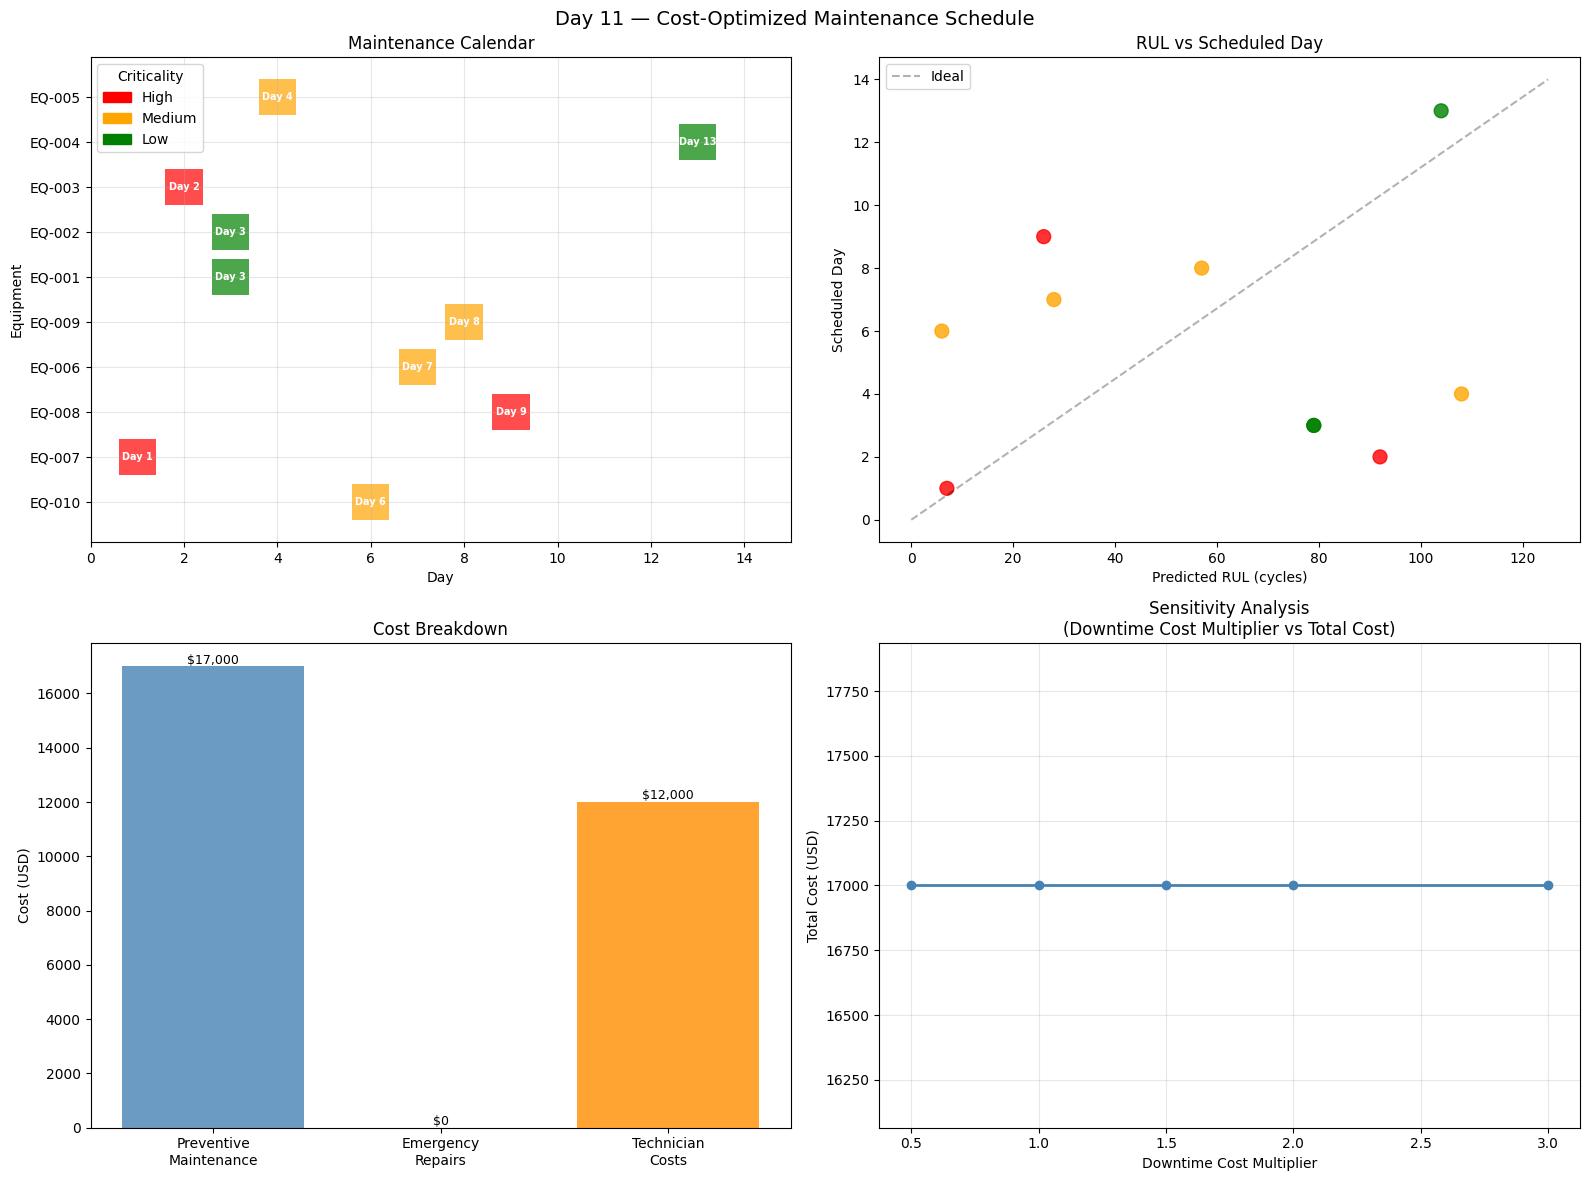

✅ Plots saved!


In [10]:
# ============================================
# CELL 9 - Visualizations
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Maintenance Calendar
ax = axes[0,0]
colors_map = {
    'High'  : 'red',
    'Medium': 'orange',
    'Low'   : 'green'
}

for idx, row in schedule_df.iterrows():
    if row['scheduled_day'] != 'N/A':
        day = int(row['scheduled_day'])
        color = colors_map.get(
            row['criticality'], 'blue'
        )
        ax.barh(
            row['equipment_id'],
            0.8, left=day-0.4,
            color=color, alpha=0.7
        )
        ax.text(
            day, idx,
            f"Day {day}",
            ha='center', va='center',
            fontsize=7, color='white',
            fontweight='bold'
        )

ax.set_xlim(0, HORIZON+1)
ax.set_title('Maintenance Calendar')
ax.set_xlabel('Day')
ax.set_ylabel('Equipment')
patches = [
    mpatches.Patch(color='red',    label='High'),
    mpatches.Patch(color='orange', label='Medium'),
    mpatches.Patch(color='green',  label='Low')
]
ax.legend(handles=patches, title='Criticality')
ax.grid(True, alpha=0.3)

# Plot 2: RUL vs Scheduled Day
scheduled = schedule_df[
    schedule_df['scheduled_day'] != 'N/A'
].copy()
scheduled['scheduled_day'] = scheduled[
    'scheduled_day'
].astype(int)

axes[0,1].scatter(
    scheduled['predicted_rul'],
    scheduled['scheduled_day'],
    c=scheduled['criticality'].map({
        'High':'red','Medium':'orange','Low':'green'
    }),
    s=100, alpha=0.8
)
axes[0,1].plot(
    [0, 125], [0, 14],
    'k--', alpha=0.3, label='Ideal'
)
axes[0,1].set_title('RUL vs Scheduled Day')
axes[0,1].set_xlabel('Predicted RUL (cycles)')
axes[0,1].set_ylabel('Scheduled Day')
axes[0,1].legend()

# Plot 3: Cost Breakdown
cost_data = {
    'Preventive\nMaintenance': schedule_df[
        'preventive_cost'
    ].sum(),
    'Emergency\nRepairs'     : schedule_df[
        'failure_cost'
    ].sum(),
    'Technician\nCosts'      : len(scheduled) *
                               COSTS['technician_hourly'] *
                               COSTS['maintenance_hours']
}
bars = axes[1,0].bar(
    cost_data.keys(),
    cost_data.values(),
    color=['steelblue','red','darkorange'],
    alpha=0.8
)
axes[1,0].set_title('Cost Breakdown')
axes[1,0].set_ylabel('Cost (USD)')
for bar, val in zip(bars, cost_data.values()):
    axes[1,0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 100,
        f'${val:,.0f}',
        ha='center', fontsize=9
    )

# Plot 4: Sensitivity Analysis
axes[1,1].plot(
    downtime_multipliers, total_costs,
    'o-', color='steelblue', linewidth=2
)
axes[1,1].set_title('Sensitivity Analysis\n(Downtime Cost Multiplier vs Total Cost)')
axes[1,1].set_xlabel('Downtime Cost Multiplier')
axes[1,1].set_ylabel('Total Cost (USD)')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle(
    'Day 11 — Cost-Optimized Maintenance Schedule',
    fontsize=14
)
plt.tight_layout()
plt.savefig(
    '../notebooks/day11_maintenance_schedule.png',
    dpi=150
)
plt.show()
print("✅ Plots saved!")

In [11]:
# ============================================
# CELL 10 - Final Summary
# ============================================

total_preventive = schedule_df['preventive_cost'].sum()
total_failure    = schedule_df['failure_cost'].sum()
total_technician = len(scheduled) * \
                   COSTS['technician_hourly'] * \
                   COSTS['maintenance_hours']
total_cost       = total_preventive + \
                   total_failure + \
                   total_technician

print("\n" + "="*55)
print("📊 DAY 11 - MAINTENANCE SCHEDULER SUMMARY")
print("="*55)
print(f"""
  Optimization:
    • Solver       : PuLP CBC
    • Horizon      : {HORIZON} days
    • Solve Time   : {solve_time:.2f}s

  Results:
    • Scheduled    : {(schedule_df['status']=='✅ Scheduled').sum()} equipment
    • Will Fail    : {(schedule_df['status']=='❌ Will Fail').sum()} equipment

  Costs:
    • Preventive   : ${total_preventive:,.2f}
    • Emergency    : ${total_failure:,.2f}
    • Technician   : ${total_technician:,.2f}
    • TOTAL        : ${total_cost:,.2f}

  Constraints Met:
    • Max {MAX_MAINTENANCE_PER_DAY} maintenance/day  ✅
    • {TECHNICIANS_PER_DAY} technicians/day         ✅
    • RUL deadline respected          ✅
    • High criticality prioritized    ✅
""")
print("="*55)
print("✅ Day 11 Complete!")


📊 DAY 11 - MAINTENANCE SCHEDULER SUMMARY

  Optimization:
    • Solver       : PuLP CBC
    • Horizon      : 14 days
    • Solve Time   : 1.12s

  Results:
    • Scheduled    : 10 equipment
    • Will Fail    : 0 equipment

  Costs:
    • Preventive   : $17,000.00
    • Emergency    : $0.00
    • Technician   : $12,000.00
    • TOTAL        : $29,000.00

  Constraints Met:
    • Max 2 maintenance/day  ✅
    • 3 technicians/day         ✅
    • RUL deadline respected          ✅
    • High criticality prioritized    ✅

✅ Day 11 Complete!
